In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Just to get the files
major_folder = 'data'

for file in os.listdir(major_folder):
    filepath = os.path.join(major_folder, file)
    print(filepath)

data\consolidated_data.xlsx
data\[Provincial] Reduction - Cebu - Phase 1B (R).csv
data\[Provincial] Reduction - Cebu - Phase 2B-Year 2 & 3 (R).csv
data\[Provincial] Reduction - Cebu - Section I (R).csv
data\[Provincial] Reduction - Cebu - Section II (R).csv
data\[Provincial] Reduction - Cebu - Section III (R).csv
data\[Provincial] Reduction - Cebu - Section IV (R).csv
data\[Provincial] Reduction - Cebu - Section V (R).csv
data\[Provincial] Reduction - Cebu - Section VI (R).csv
data\[Provincial] Reduction - Cebu - Section VII (R).csv


# Phase IB - Labor Demand

The stacked bar chart below shows the labor demand across sectors. Construction and manufacturing sectors have the highest number of jobs, but the urgency of these roles varies. Jobs are classified as high priority if 500 or more workers are needed, medium priority if 100–499 workers are required, and low priority if fewer than 100 workers are needed within the next 1–3 years. In construction, most positions are low or medium priority, suggesting that while many roles exist, few are immediately urgent. Manufacturing, however, has a substantial share of high-priority jobs, highlighting positions that companies need quickly and in large numbers.

This distinction is critical for TESDA Cebu’s planning. The chart reflects the number of distinct job titles, not the total labor demand, meaning sectors with many medium-priority roles could still require a large workforce overall. To ensure resources are invested wisely (whether through proper allocation of student scholarships, new training programs, or expanded centers), TESDA should look beyond the counts of the job and consider actual workforce needs.

In [4]:
# Open up phase 1b
phase_1b = 'data/[Provincial] Reduction - Cebu - Phase 1B (R).csv'

pretty_phase_1b_names = {
    'Program\nType':'Program Type', 
    'Priority\nRanking\n(Province)':'Priority Ranking (Province)', 
    'For Supermarket\n(Dropdown Selection)' : "For Supermarket (Dropdown Selection)"
}

# Select columns 3 to 10 and column 12 (0-indexed)
cols_to_keep = np.r_[3:10, 11]  
phase_1b_df = pd.read_csv(phase_1b, header=1).rename(columns=pretty_phase_1b_names).iloc[:, cols_to_keep]

# Define the desired order
priority_order = ['HIGH', 'MEDIUM', 'LOW']

# Convert the column to an ordered categorical
phase_1b_df['Priority Ranking (Province)'] = pd.Categorical(
    phase_1b_df['Priority Ranking (Province)'],
    categories=priority_order,
    ordered=True
)


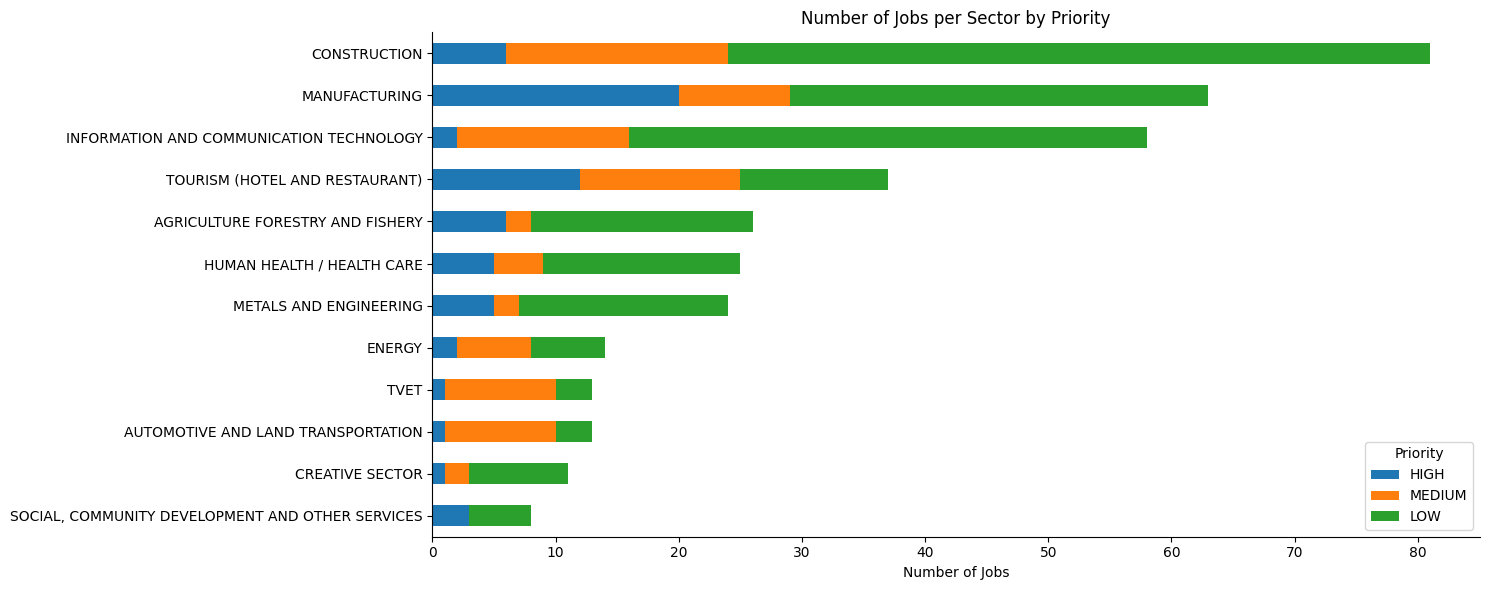

In [5]:
# Create crosstab
sector_priority = pd.crosstab(
    phase_1b_df['Sector'],
    phase_1b_df['Priority Ranking (Province)']
)

# Filter out sectors with very few jobs
sector_priority = sector_priority[sector_priority.sum(axis=1) > 5]

# Sort sectors by total jobs (sum of all priorities) in descending order
sector_priority['Total'] = sector_priority.sum(axis=1)
sector_priority = sector_priority.sort_values('Total', ascending=False)
sector_priority = sector_priority.drop(columns='Total')

# Define colors
colors = {'HIGH': '#1f77b4', 'MEDIUM': '#ff7f0e', 'LOW': '#2ca02c'}

# Plot horizontal stacked bar chart
sector_priority.plot(
    kind='barh',
    stacked=True,
    color=[colors[col] for col in sector_priority.columns],
    figsize=(15,6)
)

plt.title('Number of Jobs per Sector by Priority')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.legend(title='Priority')
#plt.legend(title='Priority', bbox_to_anchor=(1.05, 1))
plt.gca().invert_yaxis()  # Highest total jobs on top

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# Phase 2B - Cebu’s Technical and Service Sectors Exhibit the Largest Supply Gaps

In [8]:
phase_2b_df.columns

Index(['Importing 1.1\n(Identifier from Pooling)\n[Region|Province|Sector|Sub|Job|Program|Type|Rank]',
       'Region', 'Province', 'Sector', 'Subsector', 'Jobs Requirements',
       'Program', 'Program\nType', 'Priority\nRanking\n(Province)',
       'Unnamed: 9', 'Supply Gap', 'Year 2', 'Year 3', 'Year 2.1', 'Year 3.1',
       'Year 2.2', 'Year 3.2', 'Year 2.3', 'Year 3.3', 'Year 2.4', 'Year 3.4'],
      dtype='object')

In [7]:
phase_2b = 'data/[Provincial] Reduction - Cebu - Phase 2B-Year 2 & 3 (R).csv'
phase_2b_df = pd.read_csv(phase_2b, header=1).iloc[2:]
phase_2b_df['Supply Gap'] = pd.to_numeric(phase_2b_df['Supply Gap'].str.replace(',', ''))
phase_2b_df.groupby('Sector')['Supply Gap'].sum().sort_values()

Sector
FURNITURE AND FIXTURES                                1609
PROCESSED FOOD & BEVERAGES                            2267
ELECTRICAL & ELECTRONICS                              4620
GARMENTS                                              4992
MARITIME                                              6198
CREATIVE SECTOR                                      22303
SOCIAL, COMMUNITY DEVELOPMENT AND OTHER SERVICES     30755
AGRICULTURE FORESTRY AND FISHERY                     45214
ENERGY                                               50668
AUTOMOTIVE AND LAND TRANSPORTATION                   54282
METALS AND ENGINEERING                               72229
HUMAN HEALTH / HEALTH CARE                           88091
INFORMATION AND COMMUNICATION TECHNOLOGY            149772
TOURISM (HOTEL AND RESTAURANT)                      179663
MANUFACTURING                                       194103
CONSTRUCTION                                        319933
TVET                                             

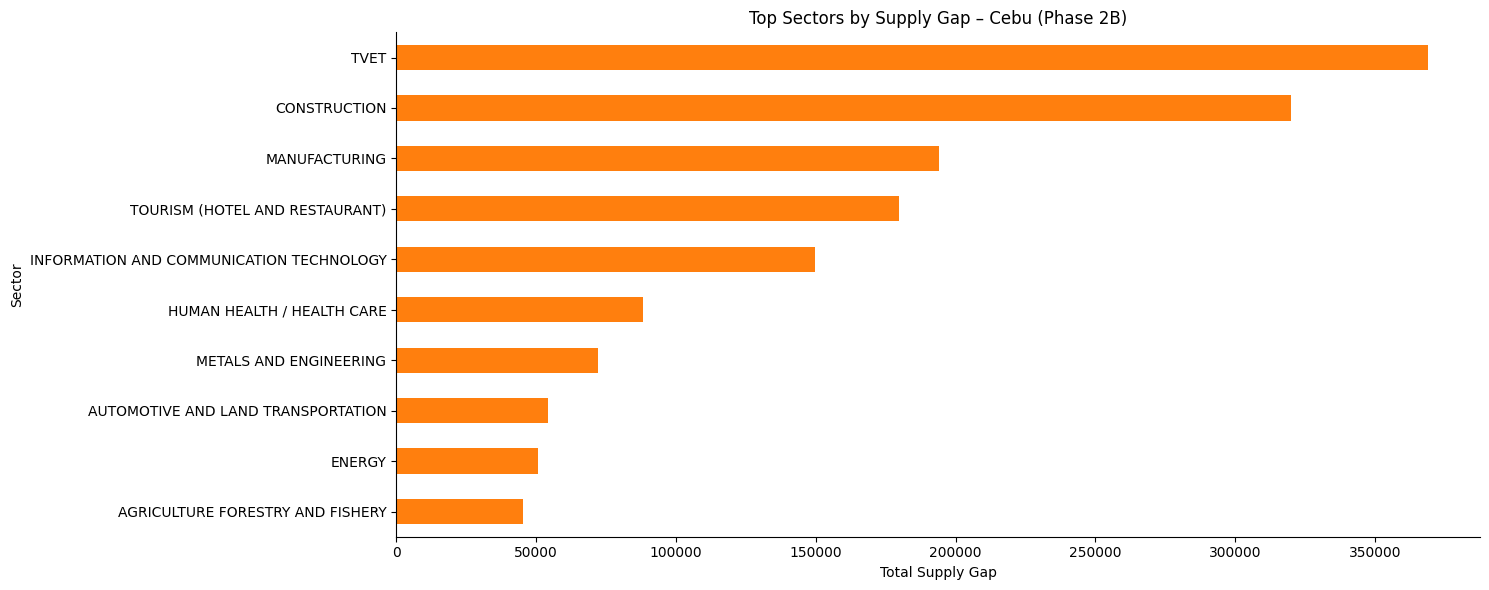

In [16]:
import matplotlib.pyplot as plt

# Compute total supply gap per sector
supply_gap_by_sector = (
    phase_2b_df.groupby('Sector')['Supply Gap'].sum().sort_values(ascending=False)
)

# Select top 10 sectors and reverse order for plotting (largest on top)
top_sectors = supply_gap_by_sector.head(10).sort_values(ascending=True)

# Plot
plt.figure(figsize=(15, 6))
top_sectors.plot(kind='barh', color='#ff7f0e')

# Chart formatting
plt.title("Top Sectors by Supply Gap – Cebu (Phase 2B)")
plt.xlabel("Total Supply Gap")
plt.ylabel("Sector")

# Clean style
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Cebu’s labor market shows significant unmet demand across technical and service sectors. The largest supply gaps are in TVET, Construction, and Manufacturing, followed by Tourism, ICT, and Health Care, underscoring the need to expand training capacity in high-growth, skills-intensive industries.

# Section 1 - TESDA properly allocates the available scholarships to the priority jobs.

The grouped bar chart below shows the number of targeted scholars across sectors for Year 2 and Year 3. Construction, Tourism (Hotel & Restaurant), Manufacturing, and ICT receive the highest number of scholars, reflecting TESDA’s alignment of labor supply with sectoral demand. Most sectors show similar numbers between the two years, indicating a consistent proportional allocation of scholars rather than arbitrary changes. Smaller sectors, such as Furniture & Fixtures or Processed Food & Beverages, receive fewer scholars, which corresponds to their relatively lower labor demand.

This distinction is important for TESDA Cebu’s planning. TESDA appears to be effectively assigning scholarships, focusing on sectors and roles that are high priority, ensuring that the supply of trained workers matches the jobs most in demand.

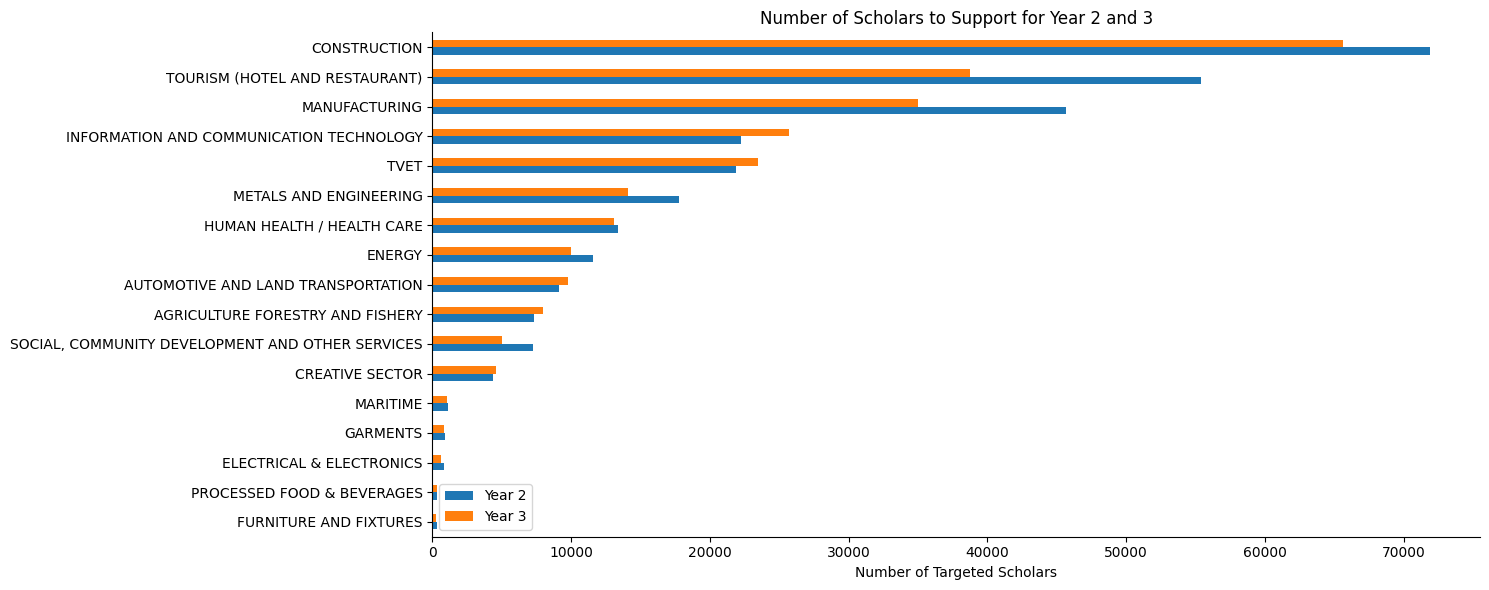

In [ ]:
section_1 = 'data/[Provincial] Reduction - Cebu - Section I (R).csv'
section_1_df = pd.read_csv(section_1, header=2).iloc[2:]

# Convert the numeric vols
cols_to_convert = ['Target Beneficiaries', 'Target Beneficiaries.1']
for col in cols_to_convert:
    section_1_df[col] = pd.to_numeric(
        section_1_df[col].str.replace(',', ''), errors='coerce'
    ).fillna(0).astype(int)


# Group once
grouped = section_1_df.groupby('Sector')[['Target Beneficiaries', 'Target Beneficiaries.1']].sum()

# Plot grouped horizontal bar chart
grouped = grouped.sort_values(by='Target Beneficiaries')

grouped.plot(kind='barh', figsize=(15, 6), color=['#1f77b4', '#ff7f0e'])

plt.xlabel('Number of Targeted Scholars')
plt.ylabel('')
plt.title('Number of Scholars to Support for Year 2 and 3')
plt.legend(['Year 2', 'Year 3'])

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


# Section 2 - The number of institutions for teaching matches the labor demand and supply. However, there is a lag since there are less institutions for year 2 (94 in total) compared to year 3 (257 in total).

The grouped bar chart below shows the number of training institutions across sectors for Year 2 and Year 3. Tourism, Construction, Manufacturing, and ICT consistently have the highest number of institutions, indicating TESDA’s sustained support for sectors with high labor demand. Year-to-year fluctuations are minor, and most sectors show similar numbers across both years, reflecting a steady, proportional allocation rather than arbitrary changes. Smaller sectors, such as Furniture & Fixtures or Processed Food & Beverages, continue to receive fewer institutions, consistent with their lower workforce needs. Overall, TESDA Cebu appears to maintain a balanced distribution of training capacity, ensuring that the supply of skilled workers aligns with sectoral demand.

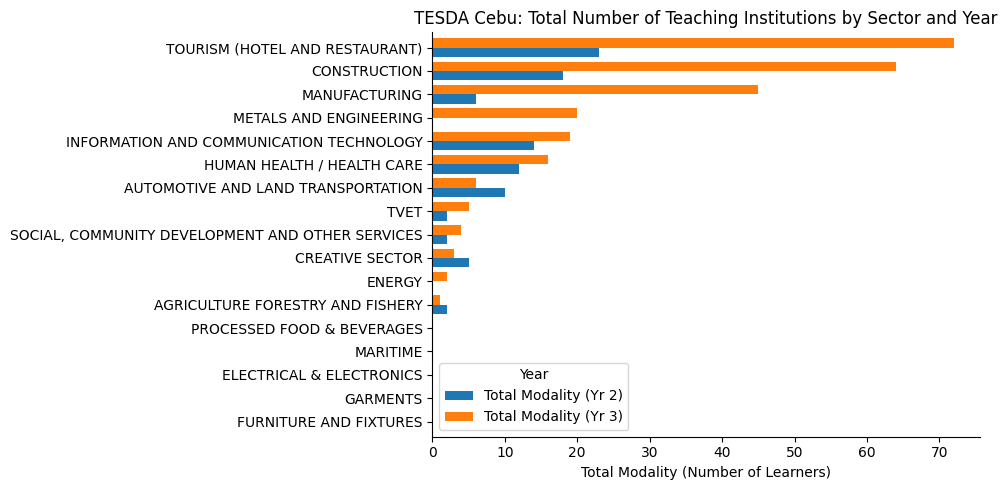

In [ ]:
#
section_2 = 'data/[Provincial] Reduction - Cebu - Section II (R).csv'
section_2_df = pd.read_csv(section_2, header=1, skiprows=2)

section_2_df = section_2_df.rename(columns={
    'Unnamed: 3': 'Sector',
    'Unnamed: 13': 'Total Modality (Yr 2)',
    'Unnamed: 22': 'Total Modality (Yr 3)'
})

# Convert the renamed columns to integers
section_2_df['Total Modality (Yr 2)'] = section_2_df['Total Modality (Yr 2)'].astype(int)
section_2_df['Total Modality (Yr 3)'] = section_2_df['Total Modality (Yr 3)'].astype(int)

# Group by Sector and sum
grouped = section_2_df.groupby('Sector')[['Total Modality (Yr 2)','Total Modality (Yr 3)']].sum().sort_values(by='Total Modality (Yr 3)')


ax = grouped[['Total Modality (Yr 2)', 'Total Modality (Yr 3)']].plot(kind='barh', figsize=(10, 5), width=0.8)
ax.set_xlabel("Total Modality (Number of Learners)")
ax.set_ylabel("")
ax.set_title("TESDA Cebu: Total Number of Teaching Institutions by Sector and Year")
plt.legend(title="Year")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# Section 3 - Three partners were found to help with the new and emerging jobs in the Industry and Healthcare sectors.



This table shows TESDA Cebu’s support for emerging jobs, with priority levels indicating the urgency of labor demand. Training providers include medical institutions and industry associations. Interestingly, every job has an identical budget of PHP 474,700, which is unusual and raises questions about the accuracy or rationale behind these allocations.

| Job Title                           | Priority | Training Provider(s)                                                                                    | Budget (PHP) |
| ----------------------------------- | -------- | ------------------------------------------------------------------------------------------------------- | ------------ |
| Industrial Sewing Machine Operators | Low      | MetrologyX Training and Assessment Center Inc.                                                          | 474,700      |
| Medical Auxiliary Support           | High     | The Hospital at Maayo (THAM), San Lucas Medical (SLM)                                                   | 474,700      |
| Medical Receptionist                | High     | Department of Health (DOH), Philippine Medical Association (PMA), Philippine Hospital Association (PHA) | 474,700      |
| Boiler Technicians                  | Low      | Hotel Resort and Restaurant Association of Cebu, Inc.                                                   | 474,700      |
| Community-Based Trainers            | Low      | Department of Health (DOH), Philippine Medical Association (PMA), Philippine Hospital Association (PHA) | 474,700      |
| Medical Secretary                   | High     | Department of Health (DOH), Philippine Medical Association (PMA), Philippine Hospital Association (PHA) | 474,700      |


# Section 4 – Strong Training Completion but Persistent Bottlenecks in Assessment Participation

In [ ]:
section_4 = 'data/[Provincial] Reduction - Cebu - Section IV (R).csv'
section_4_df = pd.read_csv(section_4)

In [ ]:
import plotly.express as px

# Data from your table
stages = ['Enrolled (E)', 'Graduated (G)', 'Assessed (A)', 'Certified (C)']
numbers = [527452, 474812, 261290, 242840]

# Calculate percentage relative to first stage and drop percentages
percent_relative = [n / numbers[0] * 100 for n in numbers]
percent_drop = [0] + [((numbers[i-1] - numbers[i]) / numbers[i-1]) * 100 for i in range(1, len(numbers))]

# Text labels showing both retention and stage name
text_labels = [
    f"{stage}<br>{percent_relative[i]:.2f}% of Enrolled<br>-{percent_drop[i]:.2f}% from prev."
    for i, stage in enumerate(stages)
]

# Build funnel chart
fig = px.funnel(
    x=numbers,
    y=stages,
    text=text_labels
)

# Customize appearance
fig.update_traces(marker_color="#be2328")  # dark red
fig.update_layout(
    title="TESDA Year 2 – Institution-Based Training Funnel",
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(
        family="Times New Roman, Times, serif",
        size=14,
        color="black"
    )
)
fig.update_yaxes(showticklabels=False, title='')

fig.show()


Strong training completion is observed, but there is major attrition before assessment.  
Graduation efficiency remains high at around 90%, while certification success among those assessed is projected to stay strong at about 93% in Year 3.  
However, fewer graduates are expected to proceed to assessment, leading to a small decline in overall certification yield — from approximately 46% to 43% of enrollees between Year 2 and Year 3.  

In summary, training delivery is steady and effective, but assessment participation remains the key bottleneck to certification growth.


## Section 5 - Slight Decline in Enterprise-Based Training Partnerships but Continued Industry Participation

In [18]:
section_5 = 'data/[Provincial] Reduction - Cebu - Section V (R).csv'
section_5_df = pd.read_csv(section_5)

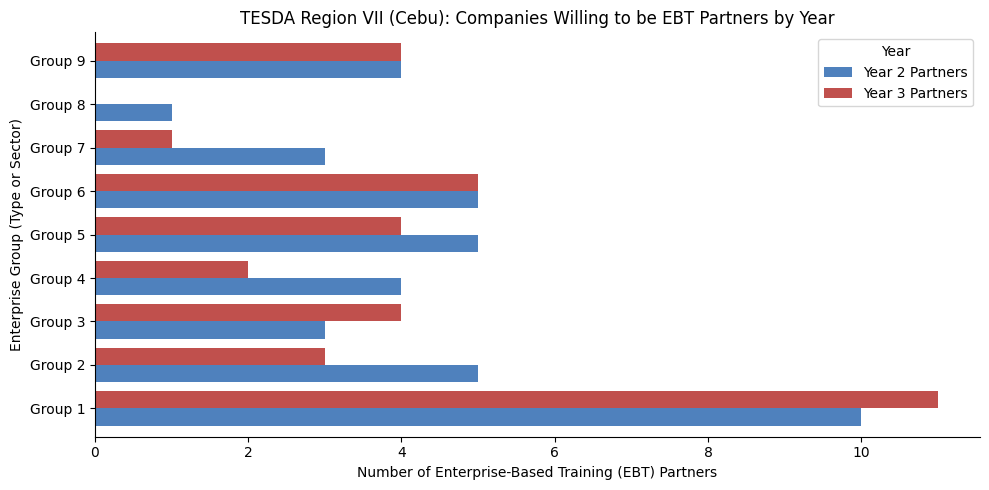

The chart shows that Enterprise-Based Training (EBT) partnerships in Region VII declined slightly from 42 in Year 2 to 34 in Year 3, a modest 19 percent decrease. Despite this, enterprise engagement remains stable, with Group 1 showing slight growth (10 to 11 partners) and Groups  and 9 maintaining steady participation of around four to five companies each. In contrast, Groups 2, 4, 5, 7, and 8 experienced drops in partnerships, likely due to project cycles or limited training capacity among smaller firms. Overall, the data suggests a gradual decline in enterprise participation, highlighting the need to re-engage more companies in EBT partnerships. Moreover, it is recommended that TESDA specify the criteria or industry composition of each group to improve clarity and interpretation of partnership trends.


# Section 6

In [ ]:
section_6 = 'data/[Provincial] Reduction - Cebu - Section VI (R).csv'
section_6_df = pd.read_csv(section_6)

C:\Users\Raymond\AppData\Local\Temp\ipykernel_3208\4201194255.py:27: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



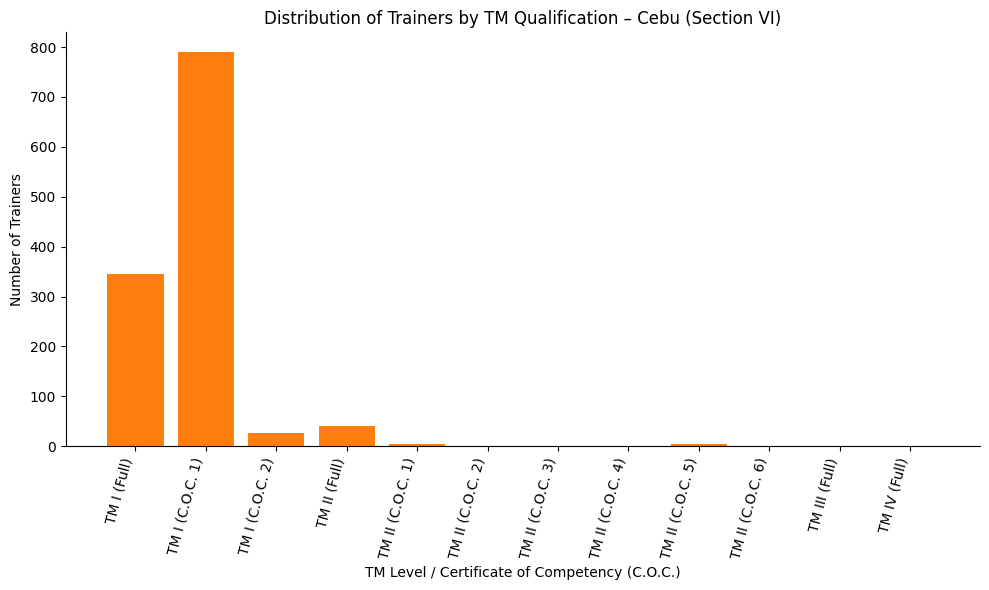

In [ ]:
import matplotlib.pyplot as plt

# Data
tm_levels = [
    "TM I (Full)",
    "TM I (C.O.C. 1)",
    "TM I (C.O.C. 2)",
    "TM II (Full)",
    "TM II (C.O.C. 1)",
    "TM II (C.O.C. 2)",
    "TM II (C.O.C. 3)",
    "TM II (C.O.C. 4)",
    "TM II (C.O.C. 5)",
    "TM II (C.O.C. 6)",
    "TM III (Full)",
    "TM IV (Full)"
]

values = [345, 790, 26, 41, 4, 0, 1, 0, 4, 1, 0, 0]

# Plot
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(tm_levels, values, color='#ff7f0e')
ax.set_title("Distribution of Trainers by TM Qualification – Cebu (Section VI)")
ax.set_xlabel("TM Level / Certificate of Competency (C.O.C.)")
ax.set_ylabel("Number of Trainers")
ax.set_xticklabels(tm_levels, rotation=75, ha='right')
# ax.grid(axis='y', linestyle='--', alpha=0.7)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Cebu’s pool of TM-certified trainers remains heavily concentrated at the TM I level, particularly those qualified to deliver training sessions (C.O.C. 1). This indicates strong capacity for instructional delivery but limited ability for curriculum design and system development. Only a small number of trainers hold TM II qualifications, and virtually none are certified at TM III–IV, revealing a critical gap in higher-level training design, quality assurance, and institutional leadership. The scarcity of trainers in key TM II functions such as developing curricula, learning materials, and assessment tools constrains Cebu’s ability to expand and modernize training programs. Overall, the province demonstrates a broad but shallow trainer base—competent in delivering instruction but requiring strategic investment in trainer upgrading and methodology advancement to strengthen program sustainability and responsiveness to evolving industry needs.

# Section 7 

In [ ]:
section_7 = 'data/[Provincial] Reduction - Cebu - Section VII (R).csv'
section_7_df = pd.read_csv(section_7)

In [ ]:
section_7_df.groupby('Sector')[assessor_df.columns].sum()

,Total: 362,Total: 362.1,Total: 362.2,Total: 362.3
Sector,,,,
AGRICULTURE FORESTRY AND FISHERY,16,16,16,16
AUTOMOTIVE AND LAND TRANSPORTATION,17,17,17,17
CONSTRUCTION,191,191,191,191
CREATIVE SECTOR,9,9,9,9
ELECTRICAL & ELECTRONICS,0,0,0,0
ENERGY,18,18,18,18
FURNITURE AND FIXTURES,0,0,0,0
GARMENTS,0,0,0,0
HUMAN HEALTH / HEALTH CARE,29,29,29,29


In [ ]:
assessor_df.columns

Index(['Total: 362', 'Total: 362.1', 'Total: 362.2', 'Total: 362.3'], dtype='object')

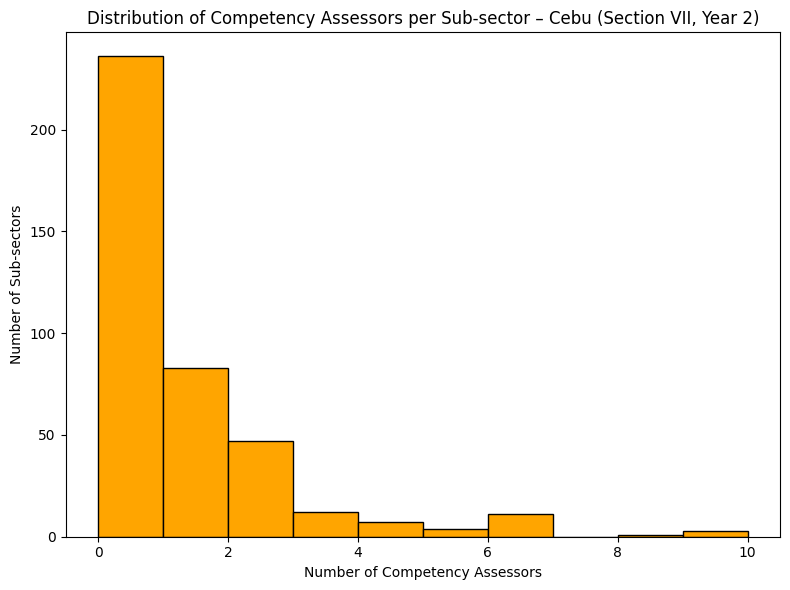

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the file (skip extra header rows so real headers are used)
section_7_path = "data/[Provincial] Reduction - Cebu - Section VII (R).csv"
section_7_df = pd.read_csv(section_7_path, skiprows=3)

# ✅ Select only the Competency Assessors column for Year 2
# (based on your sheet, this column header is "Total: 362")
year2_col = "Total: 362"

# Convert to numeric (in case of text or missing values)
assessor_counts = pd.to_numeric(section_7_df[year2_col], errors="coerce").fillna(0)

# --- Create histogram for Year 2 ---
plt.figure(figsize=(8, 6))
max_count = int(assessor_counts.max()) if len(assessor_counts) else 0
bins = range(0, max_count + 2)

plt.hist(assessor_counts, bins=bins, color='orange', edgecolor='black')

plt.title("Distribution of Competency Assessors per Sub-sector – Cebu (Section VII, Year 2)")
plt.xlabel("Number of Competency Assessors")
plt.ylabel("Number of Sub-sectors")
plt.tight_layout()
plt.show()


The histogram shows that nearly all Cebu subsectors have fewer than two competency assessors, and the majority have none at all. This pattern signals a critical shortage in assessment capacity, making assessor development a top regional priority. Without adequate assessors, TESDA Region VII’s training outcomes cannot translate into certifications, especially in emerging and high-demand fields like agri-tourism and smart irrigation.

A targeted “Assessor Pool Development Program” or cross-provincial assessor sharing may be needed to unlock bottlenecks and sustain certification growth.